urls = Array.from(document.querySelectorAll('.rg_i')).map(el=> el.hasAttribute('data-src')?el.getAttribute('data-src'):el.getAttribute('data-iurl'));
window.open('data:text/csv;charset=utf-8,' + escape(urls.join('\n')));

In [ ]:
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


# СОЗДАНИЕ СОБСТВЕННОГО ДАТАСЕТА

**Создаем папки и классы, закачиваем изображения, удаляем файлы csv**

In [ ]:
from fastai.vision import *
import shutil
import os

In [ ]:
path = Path('/content/drive/My Drive/data')

In [ ]:
folder_animals = 'animals'
file_animals = 'animals.csv'
dest_animals = path/folder_animals

folder_architecture = 'architecture'
file_architecture = 'architecture.csv'
dest_architecture = path/folder_architecture

folder_car = 'car'
file_car = 'car.csv'
dest_car = path/folder_car

folder_food = 'food'
file_food = 'food.csv'
dest_food = path/folder_food

folder_nature = 'nature'
file_nature = 'nature.csv'
dest_nature = path/folder_nature

folder_people = 'people'
file_people = 'people.csv'
dest_people = path/folder_people

In [ ]:
def create_folders (path):
  dest_animals = path/folder_animals
  dest_animals.mkdir(parents=True, exist_ok=True)

  dest_architecture = path/folder_architecture
  dest_architecture.mkdir(parents=True, exist_ok=True)

  dest_car = path/folder_car
  dest_car.mkdir(parents=True, exist_ok=True)

  dest_food = path/folder_food
  dest_food.mkdir(parents=True, exist_ok=True)

  dest_nature = path/folder_nature
  dest_nature.mkdir(parents=True, exist_ok=True)

  dest_people = path/folder_people
  dest_people.mkdir(parents=True, exist_ok=True)

In [ ]:
create_folders(path)

In [ ]:
classes = ['animals', 'architecture', 'car', 'food', 'nature', 'people']

In [ ]:
download_images(path/folder_animals/file_animals, dest_animals)
download_images(path/folder_architecture/file_architecture, dest_architecture)
download_images(path/folder_car/file_car, dest_car)
download_images(path/folder_food/file_food, dest_food)
download_images(path/folder_nature/file_nature, dest_nature)
download_images(path/folder_people/file_people, dest_people)

In [ ]:
os.remove("/content/drive/My Drive/data/animals/animals.csv") 
os.remove("/content/drive/My Drive/data/architecture/architecture.csv") 
os.remove("/content/drive/My Drive/data/car/car.csv") 
os.remove("/content/drive/My Drive/data/food/food.csv") 
os.remove("/content/drive/My Drive/data/nature/nature.csv") 
os.remove("/content/drive/My Drive/data/people/people.csv") 

**Очищаем данные вручную. Затем переименовываем все файлы, копируем их в папки для обучающей, валидационной и тестовой выборки**

In [ ]:
def rename_files (folder):
  path2 = path/folder
  listOfFiles = os.listdir(path2)
  countOfFiles = len(listOfFiles)
  os.chdir(path2)
  for i in range(0, countOfFiles):
      os.rename(listOfFiles[i], folder + str(i) + '.jpg')

In [ ]:
for c in classes:
  rename_files(c)

In [ ]:
path_train = Path('/content/drive/My Drive/train')
path_val = Path('/content/drive/My Drive/val')
path_test = Path('/content/drive/My Drive/test')

In [ ]:
create_folders(path_train)
create_folders(path_val)
create_folders(path_test)

In [ ]:
def copy_images(start, end, source_dir, dest_dir, c):
    for i in range(start, end):
        shutil.copy2(os.path.join(source_dir, c + str(i) + ".jpg"), os.path.join(dest_dir))

In [ ]:
# Часть набора данных для тестирования
test_percent = 0.10
# Часть набора данных для проверки
val_percent = 0.20

In [ ]:
for c in classes:
  listOfFiles = os.listdir(path/c)
  countOfFiles = len(listOfFiles)
  start_val = int(countOfFiles * (1 - val_percent - test_percent))
  start_test = int(countOfFiles * (1 - test_percent))
  copy_images(0, start_val, path/c, path_train/c, c)
  copy_images(start_val, start_test, path/c, path_val/c, c)
  copy_images(start_test, countOfFiles, path/c, path_test/c, c)

In [ ]:
show_data = ImageDataBunch.from_folder(path, train=".", valid_pct=0.2,
        ds_tfms=get_transforms(), size=150, num_workers=4).normalize(imagenet_stats)

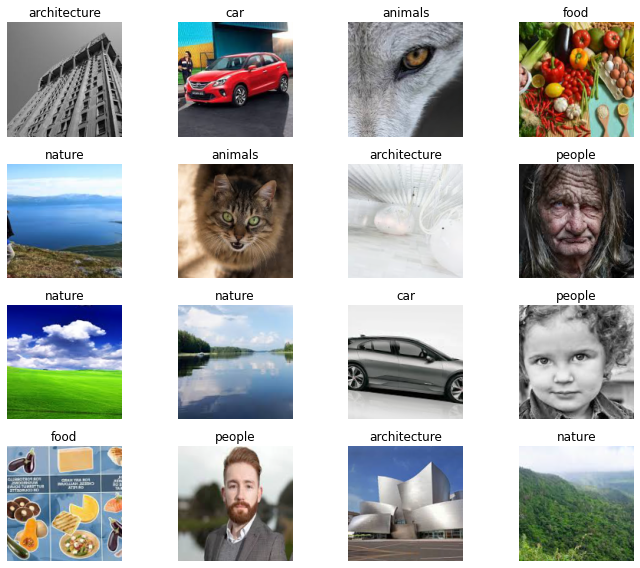

In [ ]:
show_data.show_batch(rows=4, figsize=(10,8))

# РЕАЛИЗАЦИЯ СВЕРТОЧНОЙ НЕЙРОННОЙ СЕТИ

**Генерируем датасет с аугментацией данных**

In [ ]:
from tensorflow.python.keras.preprocessing.image import ImageDataGenerator
from tensorflow.python.keras.models import Sequential, load_model
from tensorflow.python.keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.python.keras.preprocessing import image
from tensorflow.python.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
# Размеры изображения
img_width, img_height = 160, 160
# Размерность тензора на основе изображения для входных данных в нейронную сеть
# backend Tensorflow, channels_last
input_shape = (img_width, img_height, 3)
# Количество эпох
epochs = 10
# Размер мини-выборки
batch_size = 16

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1. / 255,
                                  rotation_range = 30,
                                  width_shift_range = 0.2,
                                  height_shift_range = 0.2,
                                  zoom_range = 0.2,
                                  shear_range = 0.15,
                                  horizontal_flip = True,
                                  fill_mode = 'nearest')

In [ ]:
val_datagen = ImageDataGenerator(rescale = 1. / 255,
                                horizontal_flip = True,
                                )

In [ ]:
test_datagen = ImageDataGenerator(rescale = 1. / 255)

In [ ]:
image_file_name = '/content/drive/My Drive/train/people/people107.jpg'
img = image.load_img(image_file_name, target_size=(150, 150))
plt.imshow(img)

In [ ]:
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i = 0
for batch in train_datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 4 == 0:
        break
plt.show()

In [ ]:
train_generator = train_datagen.flow_from_directory(
    path_train,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    #seed = 123,
    class_mode = 'categorical')

Found 2282 images belonging to 6 classes.


In [ ]:
val_generator = val_datagen.flow_from_directory(
    path_val,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    #seed = 123,
    class_mode = 'categorical')

Found 653 images belonging to 6 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    path_test,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    #seed = 123,
    class_mode = 'categorical')

Found 329 images belonging to 6 classes.


In [ ]:
nb_train_samples = 2282
nb_val_samples = 653
nb_test_samples = 329

**Подбираем гиперпараметры с помощью Keras Tuner**

In [ ]:
pip install -U keras-tuner

     |████████████████████████████████| 61kB 6.2MB/s 
  Created wheel for keras-tuner: filename=keras_tuner-1.0.1-cp36-none-any.whl size=73200 sha256=2e13cfe04692b8049d17c047a426cacb938f4da76a30b9d33905d85dba4bb285
  Stored in directory: /root/.cache/pip/wheels/b9/cc/62/52716b70dd90f3db12519233c3a93a5360bc672da1a10ded43
  Created wheel for terminaltables: filename=terminaltables-3.1.0-cp36-none-any.whl size=15356 sha256=69490da45a6a148f21ca73662bf20d67b9f318af23d0e3957f0059350928de40
  Stored in directory: /root/.cache/pip/wheels/30/6b/50/6c75775b681fb36cdfac7f19799888ef9d8813aff9e379663e
Successfully built keras-tuner terminaltables


In [ ]:
from kerastuner.tuners import RandomSearch, BayesianOptimization

In [ ]:
def create_model(hp):
  model = Sequential()

  model.add(Conv2D(hp.Int("conv_input_units", 32, 128, 32), (3,3), input_shape = input_shape, activation = 'relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  for i in range(hp.Int("num_conv_layers_1+", 1, 8)):
    model.add(Conv2D(hp.Int("conv_input_units_" + str(i), 64, 256, 32), (3,3), activation = 'relu'))
  
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Flatten())
  model.add(Dense(hp.Int("dense_input_units", 128, 512, 64), activation = 'relu'))

  model.add(Dropout(0.5))
  model.add(Dense(6, activation = 'softmax'))

  model.compile(optimizer='adam',
                loss="categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [ ]:
#################
def create_model(hp):
  model = Sequential()

  model.add(Conv2D(64, (3,3), input_shape = input_shape, activation = 'relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  for i in range(hp.Int("num_layers_1+", 1, 4)):
    model.add(Conv2D(hp.Int("conv_input_units_" + str(i), 64, 256, 32), (3,3), activation = 'relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Flatten())
  model.add(Dense(224, activation = 'relu'))
  model.add(Dropout(0.5))
  model.add(Dense(6, activation = 'softmax'))

  model.compile(optimizer='adam',
                loss="categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [ ]:
tuner = RandomSearch(
    create_model,                # функция создания модели
    objective='val_accuracy',    # метрика, которую нужно оптимизировать - 
    max_trials=20,               # максимальное количество запусков обучения 
    )

In [ ]:
tuner.search_space_summary()

In [ ]:
tuner.search(train_generator,
             validation_data = val_generator,
             batch_size=batch_size,            # Размер мини-выборки
             epochs=30,
             )

Epoch 1/30
72/72 [==============================] - 2325s 32s/step - loss: 1.9784 - accuracy: 0.3606 - val_loss: 1.2474 - val_accuracy: 0.5314
Epoch 2/30
72/72 [==============================] - 25s 352ms/step - loss: 1.2896 - accuracy: 0.5403 - val_loss: 1.1822 - val_accuracy: 0.5881
Epoch 3/30
72/72 [==============================] - 22s 300ms/step - loss: 1.1286 - accuracy: 0.5876 - val_loss: 1.2639 - val_accuracy: 0.5620
Epoch 4/30
72/72 [==============================] - 25s 352ms/step - loss: 1.0580 - accuracy: 0.6117 - val_loss: 1.0387 - val_accuracy: 0.6432
Epoch 5/30
72/72 [==============================] - 26s 356ms/step - loss: 0.9762 - accuracy: 0.6450 - val_loss: 0.9772 - val_accuracy: 0.6815
Epoch 6/30
72/72 [==============================] - 26s 360ms/step - loss: 0.9352 - accuracy: 0.6683 - val_loss: 0.8917 - val_accuracy: 0.7182
Epoch 7/30
72/72 [==============================] - 21s 297ms/step - loss: 0.9210 - accuracy: 0.6599 - val_loss: 0.9402 - val_accuracy: 0.6616

Epoch 1/30
72/72 [==============================] - 24s 329ms/step - loss: 1.8030 - accuracy: 0.2095 - val_loss: 1.6055 - val_accuracy: 0.3216
Epoch 2/30
72/72 [==============================] - 22s 308ms/step - loss: 1.6200 - accuracy: 0.3142 - val_loss: 1.5781 - val_accuracy: 0.3216
Epoch 3/30
72/72 [==============================] - 23s 313ms/step - loss: 1.5648 - accuracy: 0.3216 - val_loss: 1.5490 - val_accuracy: 0.3507
Epoch 4/30
72/72 [==============================] - 23s 313ms/step - loss: 1.4853 - accuracy: 0.4067 - val_loss: 1.3312 - val_accuracy: 0.4855
Epoch 5/30
72/72 [==============================] - 22s 303ms/step - loss: 1.4321 - accuracy: 0.4378 - val_loss: 1.4623 - val_accuracy: 0.3828
Epoch 6/30
72/72 [==============================] - 22s 303ms/step - loss: 1.4267 - accuracy: 0.4089 - val_loss: 1.4107 - val_accuracy: 0.3997
Epoch 7/30
72/72 [==============================] - 22s 304ms/step - loss: 1.3719 - accuracy: 0.4387 - val_loss: 1.3819 - val_accuracy: 0.4472

Epoch 1/30
72/72 [==============================] - 25s 348ms/step - loss: 1.8286 - accuracy: 0.1757 - val_loss: 1.7905 - val_accuracy: 0.1838
Epoch 2/30
72/72 [==============================] - 24s 329ms/step - loss: 1.7905 - accuracy: 0.1840 - val_loss: 1.7897 - val_accuracy: 0.1838
Epoch 3/30
72/72 [==============================] - 23s 326ms/step - loss: 1.7896 - accuracy: 0.1823 - val_loss: 1.7894 - val_accuracy: 0.1838
Epoch 4/30
72/72 [==============================] - 23s 325ms/step - loss: 1.7898 - accuracy: 0.1819 - val_loss: 1.7893 - val_accuracy: 0.1838
Epoch 5/30
72/72 [==============================] - 23s 326ms/step - loss: 1.7894 - accuracy: 0.1840 - val_loss: 1.7892 - val_accuracy: 0.1838
Epoch 6/30
72/72 [==============================] - 24s 327ms/step - loss: 1.7895 - accuracy: 0.1845 - val_loss: 1.7891 - val_accuracy: 0.1838
Epoch 7/30
72/72 [==============================] - 23s 325ms/step - loss: 1.7895 - accuracy: 0.1845 - val_loss: 1.7891 - val_accuracy: 0.1838

Epoch 1/30
72/72 [==============================] - 25s 347ms/step - loss: 1.7537 - accuracy: 0.3506 - val_loss: 1.3435 - val_accuracy: 0.4793
Epoch 2/30
72/72 [==============================] - 25s 345ms/step - loss: 1.3340 - accuracy: 0.4969 - val_loss: 1.2868 - val_accuracy: 0.5345
Epoch 3/30
72/72 [==============================] - 25s 342ms/step - loss: 1.1225 - accuracy: 0.5784 - val_loss: 0.9702 - val_accuracy: 0.6355
Epoch 4/30
72/72 [==============================] - 25s 346ms/step - loss: 1.0675 - accuracy: 0.6043 - val_loss: 0.9813 - val_accuracy: 0.6401
Epoch 5/30
72/72 [==============================] - 26s 355ms/step - loss: 0.9821 - accuracy: 0.6319 - val_loss: 0.8756 - val_accuracy: 0.6891
Epoch 6/30
72/72 [==============================] - 22s 299ms/step - loss: 0.9771 - accuracy: 0.6385 - val_loss: 0.9013 - val_accuracy: 0.6799
Epoch 7/30
72/72 [==============================] - 21s 296ms/step - loss: 0.9261 - accuracy: 0.6521 - val_loss: 0.9566 - val_accuracy: 0.6784

Epoch 1/30
72/72 [==============================] - 32s 443ms/step - loss: 2.0531 - accuracy: 0.3659 - val_loss: 1.3098 - val_accuracy: 0.4946
Epoch 2/30
72/72 [==============================] - 43s 598ms/step - loss: 1.2171 - accuracy: 0.5486 - val_loss: 1.2177 - val_accuracy: 0.5697
Epoch 3/30
72/72 [==============================] - 41s 571ms/step - loss: 1.1254 - accuracy: 0.5789 - val_loss: 1.0467 - val_accuracy: 0.6355
Epoch 4/30
72/72 [==============================] - 24s 328ms/step - loss: 1.0546 - accuracy: 0.6310 - val_loss: 1.0098 - val_accuracy: 0.6309
Epoch 5/30
72/72 [==============================] - 32s 442ms/step - loss: 1.0192 - accuracy: 0.6275 - val_loss: 1.0237 - val_accuracy: 0.6554
Epoch 6/30
72/72 [==============================] - 43s 596ms/step - loss: 0.9373 - accuracy: 0.6503 - val_loss: 0.9396 - val_accuracy: 0.6723
Epoch 7/30
72/72 [==============================] - 24s 332ms/step - loss: 0.9135 - accuracy: 0.6626 - val_loss: 0.9664 - val_accuracy: 0.6677

...

Epoch 1/30
72/72 [==============================] - 22s 305ms/step - loss: 2.0442 - accuracy: 0.3878 - val_loss: 1.3134 - val_accuracy: 0.5345
Epoch 2/30
72/72 [==============================] - 22s 301ms/step - loss: 1.2288 - accuracy: 0.5429 - val_loss: 1.2410 - val_accuracy: 0.5666
Epoch 3/30
72/72 [==============================] - 22s 300ms/step - loss: 1.1384 - accuracy: 0.5815 - val_loss: 1.0277 - val_accuracy: 0.6432
Epoch 4/30
72/72 [==============================] - 22s 301ms/step - loss: 1.0235 - accuracy: 0.6258 - val_loss: 1.0146 - val_accuracy: 0.6493
Epoch 5/30
72/72 [==============================] - 21s 298ms/step - loss: 0.9768 - accuracy: 0.6402 - val_loss: 0.9332 - val_accuracy: 0.6769
Epoch 6/30
72/72 [==============================] - 21s 298ms/step - loss: 0.9442 - accuracy: 0.6578 - val_loss: 0.8565 - val_accuracy: 0.7060
Epoch 7/30
72/72 [==============================] - 22s 308ms/step - loss: 0.8945 - accuracy: 0.6731 - val_loss: 0.8009 - val_accuracy: 0.7152

Epoch 1/30
72/72 [==============================] - 22s 308ms/step - loss: 1.8786 - accuracy: 0.3076 - val_loss: 1.7433 - val_accuracy: 0.2665
Epoch 2/30
72/72 [==============================] - 22s 305ms/step - loss: 1.4901 - accuracy: 0.4316 - val_loss: 1.2162 - val_accuracy: 0.5636
Epoch 3/30
72/72 [==============================] - 20s 280ms/step - loss: 1.3243 - accuracy: 0.5039 - val_loss: 1.1243 - val_accuracy: 0.5452
Epoch 4/30
72/72 [==============================] - 22s 301ms/step - loss: 1.1521 - accuracy: 0.5701 - val_loss: 1.0410 - val_accuracy: 0.6294
Epoch 5/30
72/72 [==============================] - 20s 281ms/step - loss: 1.1217 - accuracy: 0.6017 - val_loss: 1.0946 - val_accuracy: 0.5758
Epoch 6/30
72/72 [==============================] - 22s 301ms/step - loss: 1.0466 - accuracy: 0.6139 - val_loss: 0.9312 - val_accuracy: 0.6662
Epoch 7/30
72/72 [==============================] - 20s 281ms/step - loss: 0.9912 - accuracy: 0.6455 - val_loss: 1.0526 - val_accuracy: 0.6508

Epoch 1/30
72/72 [==============================] - 21s 294ms/step - loss: 1.8107 - accuracy: 0.2673 - val_loss: 1.5944 - val_accuracy: 0.3706
Epoch 2/30
72/72 [==============================] - 21s 293ms/step - loss: 1.4083 - accuracy: 0.4562 - val_loss: 1.1695 - val_accuracy: 0.5651
Epoch 3/30
72/72 [==============================] - 21s 291ms/step - loss: 1.3094 - accuracy: 0.4969 - val_loss: 1.0963 - val_accuracy: 0.5835
Epoch 4/30
72/72 [==============================] - 21s 293ms/step - loss: 1.1089 - accuracy: 0.5898 - val_loss: 1.0562 - val_accuracy: 0.6417
Epoch 5/30
72/72 [==============================] - 20s 282ms/step - loss: 1.0688 - accuracy: 0.5911 - val_loss: 1.0401 - val_accuracy: 0.6248
Epoch 6/30
72/72 [==============================] - 20s 282ms/step - loss: 1.0153 - accuracy: 0.6389 - val_loss: 1.2085 - val_accuracy: 0.5743
Epoch 7/30
72/72 [==============================] - 21s 292ms/step - loss: 1.0155 - accuracy: 0.6218 - val_loss: 0.8813 - val_accuracy: 0.6723

Epoch 1/30
72/72 [==============================] - 32s 448ms/step - loss: 1.7681 - accuracy: 0.3734 - val_loss: 1.2438 - val_accuracy: 0.5391
Epoch 2/30
72/72 [==============================] - 42s 580ms/step - loss: 1.2057 - accuracy: 0.5535 - val_loss: 1.2776 - val_accuracy: 0.5544
Epoch 3/30
72/72 [==============================] - 37s 510ms/step - loss: 1.0825 - accuracy: 0.6004 - val_loss: 0.9252 - val_accuracy: 0.6646
Epoch 4/30
72/72 [==============================] - 40s 559ms/step - loss: 0.9760 - accuracy: 0.6380 - val_loss: 0.9422 - val_accuracy: 0.6861
Epoch 5/30
72/72 [==============================] - 23s 320ms/step - loss: 0.9850 - accuracy: 0.6394 - val_loss: 0.9395 - val_accuracy: 0.6616
Epoch 6/30
72/72 [==============================] - 23s 322ms/step - loss: 0.9242 - accuracy: 0.6700 - val_loss: 0.9283 - val_accuracy: 0.6784
Epoch 7/30
72/72 [==============================] - 23s 320ms/step - loss: 0.8974 - accuracy: 0.6735 - val_loss: 0.9904 - val_accuracy: 0.6417

INFO:tensorflow:Oracle triggered exit


In [ ]:
tuner.results_summary()

In [ ]:
models = tuner.get_best_models(num_models=3)
best_model = tuner.get_best_models(num_models=1)[0]

In [ ]:
for model in models:
  model.summary()
  model.evaluate(test_generator)
  print() 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 158, 158, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 79, 79, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 77, 77, 160)       46240     
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 75, 75, 96)        138336    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 37, 37, 96)        0         
_________________________________________________________________
flatten (Flatten)            (None, 131424)            0         
_________________________________________________________________
dense (Dense)                (None, 320)               4

In [ ]:
best_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 158, 158, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 79, 79, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 77, 77, 160)       46240     
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 75, 75, 96)        138336    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 37, 37, 96)        0         
_________________________________________________________________
flatten (Flatten)            (None, 131424)            0         
_________________________________________________________________
dense (Dense)                (None, 320)               4

**Проектируем модель с лучшими отобранными параметрами**

In [ ]:
model = Sequential()
model.add(Conv2D(64, (3, 3), activation = 'relu', input_shape = input_shape))
model.add(Conv2D(64, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation = 'relu'))
model.add(Conv2D(128, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(256, (3, 3), activation = 'relu'))
model.add(Conv2D(256, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(6, activation = 'softmax'))

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation = 'relu', input_shape = input_shape))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(96, (3, 3), activation = 'relu'))
model.add(Conv2D(160, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(320, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(6, activation = 'softmax'))

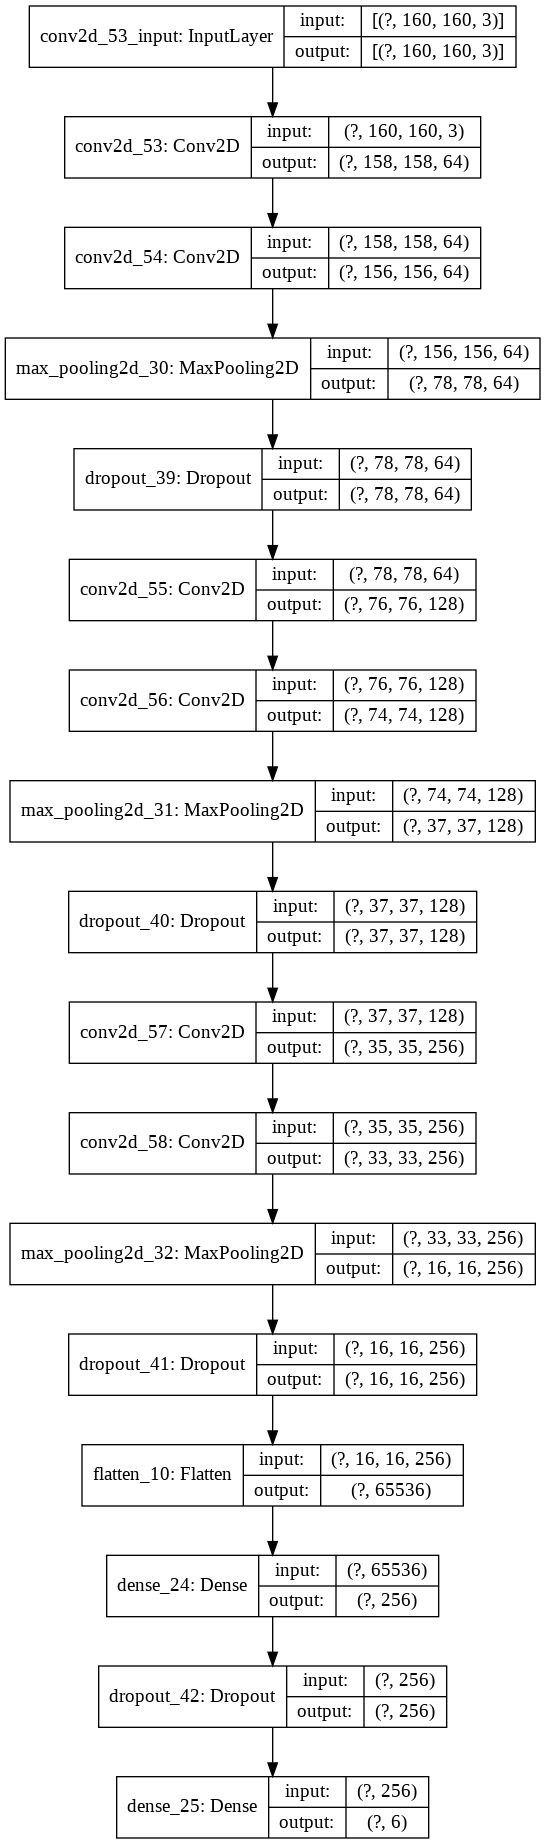

In [168]:
tf.keras.utils.plot_model(model, 
                          to_file='/content/drive/My Drive/model_plot.png', 
                          show_shapes=True, 
                          show_layer_names=True
                          )

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
early_stopping_callback = EarlyStopping(monitor = 'val_accuracy', patience = 10)

In [ ]:
history = model.fit_generator(
            train_generator,
            #steps_per_epoch = nb_train_samples // batch_size,
            epochs = 120,
            validation_data = val_generator,
            #validation_steps = nb_val_samples // batch_size,
            callbacks=[early_stopping_callback]
            #callbacks=[ReduceLROnPlateau()]
            )

Epoch 1/120
143/143 [==============================] - 22s 157ms/step - loss: 1.7365 - accuracy: 0.2441 - val_loss: 1.5815 - val_accuracy: 0.3323
Epoch 2/120
143/143 [==============================] - 22s 156ms/step - loss: 1.5501 - accuracy: 0.3361 - val_loss: 1.4920 - val_accuracy: 0.3936
Epoch 3/120
143/143 [==============================] - 22s 157ms/step - loss: 1.4815 - accuracy: 0.3812 - val_loss: 1.4844 - val_accuracy: 0.3400
Epoch 4/120
143/143 [==============================] - 23s 159ms/step - loss: 1.3731 - accuracy: 0.4479 - val_loss: 1.4046 - val_accuracy: 0.4028
Epoch 5/120
143/143 [==============================] - 23s 158ms/step - loss: 1.2467 - accuracy: 0.5206 - val_loss: 1.1617 - val_accuracy: 0.5789
Epoch 6/120
143/143 [==============================] - 22s 156ms/step - loss: 1.2248 - accuracy: 0.5232 - val_loss: 1.1576 - val_accuracy: 0.5636
Epoch 7/120
143/143 [==============================] - 23s 158ms/step - loss: 1.1540 - accuracy: 0.5438 - val_loss: 1.1889 -

In [ ]:
scores = model.evaluate_generator(test_generator, nb_test_samples // batch_size)
print("Аккуратность на тестовых данных: %.2f%%" % (scores[1]*100))

Аккуратность на тестовых данных: 77.19%


In [ ]:
model.save('/content/drive/My Drive/CNN2.h5')

**Визуализируем результаты обучения**

In [ ]:
print(history.history.keys())

NameError: ignored

In [ ]:
print(history.history['accuracy'])

[0.5304479002952576, 0.5230000019073486, 0.5359839200973511]


In [ ]:
import matplotlib.style
import matplotlib as mpl
mpl.style.use('seaborn-dark')

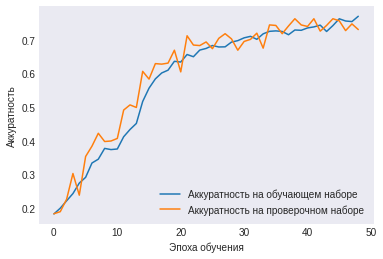

In [ ]:
plt.plot(history.history['accuracy'], label='Аккуратность на обучающем наборе')
plt.plot(history.history['val_accuracy'], label='Аккуратность на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Аккуратность')
plt.legend()
plt.show()

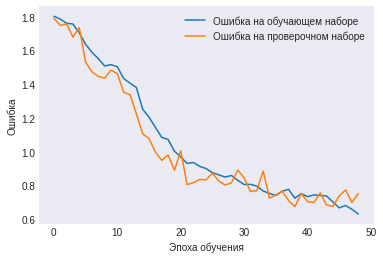

In [ ]:
plt.plot(history.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

**Тестируем полученную сеть**

In [ ]:
loaded_model = load_model('/content/drive/My Drive/CNN2.h5')

In [ ]:
loaded_model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

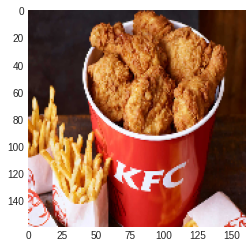

In [ ]:
img_path = '/content/KFC.jpg'
img = image.load_img(img_path, target_size=(160, 160))
plt.imshow(img)

In [ ]:
x = image.img_to_array(img)
x /= 255
x = np.expand_dims(x, axis=0)

In [ ]:
prediction = loaded_model.predict(x)
print(classes)
for i in range(0,6):
  print(prediction[:,i])

['animals', 'architecture', 'car', 'food', 'nature', 'people']
[6.434465e-09]
[7.654723e-10]
[2.847537e-13]
[1.]
[9.505632e-15]
[1.632415e-08]


In [ ]:
prediction = loaded_model.predict(x)
if max(max(prediction)) <= 0.6:
  print('others')
else: 
  print(classes[np.argmax(prediction)])

food
